# Import Libraries

In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.backend as K
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import pandas as pd
import re

from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import InputLayer, Dense, Masking, GRU, BatchNormalization, LeakyReLU

tfd = tfp.distributions
tfb = tfp.bijectors
tfpl = tfp.layers

In [ ]:
!nvidia-smi

Wed Jul  7 08:57:52 2021       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 465.27       Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   35C    P8     9W /  70W |      0MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
assert tf.config.experimental.list_physical_devices("GPU")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
% cd /content/drive/MyDrive/colab_data/socian_bangla_dataset/
!ls

/content/drive/MyDrive/colab_data/socian_bangla_dataset
bangla_neg.txt	bangla_pos.txt	cc.bn.300.vec  history.json  model


In [ ]:
from gensim.models import KeyedVectors
with tf.device("/cpu:0"):
  bn_model = KeyedVectors.load_word2vec_format('cc.bn.300.vec')
  embedding_layer = bn_model.get_keras_embedding(train_embeddings=False)

In [ ]:
def get_word2index():
  word2index = {}
  for i in range(len(bn_model.index2word)):
    word2index[bn_model.index2word[i]] = i
  
  return word2index

In [ ]:
word2index = get_word2index()

In [ ]:
def tokenize(text):
  if type(text) is str:
    text = text.split()
  
  UNK = word2index['unk']
  START = word2index['</s>']
  END = word2index['end']

  tokens = [START]
  for word in text:
    token = word2index.get(word, UNK)
    tokens.append(token)
  tokens.append(END)

  return tokens

In [ ]:
tokenize('জয় , বাংলা কাপ ! তাও আবার ? স্বাধীনতার মাস মার্চে ? !')

[1, 1526, 2, 103, 1510, 40, 2880, 211, 34, 2049, 655, 6820, 34, 40, 3732]

In [ ]:
def preprocess_sentence(sentence):
    sentence = re.sub(r'["."]+', " . ", sentence)
    sentence = re.sub(r'[";"]+', " ; ", sentence)
    sentence = re.sub(r'["?"]+', " ? ", sentence)
    sentence = re.sub(r'["!"]+', " ! ", sentence)
    sentence = re.sub(r'[","]+', " , ", sentence)
    sentence = re.sub(r'["।"]+', " । ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    
    return sentence.strip()

In [ ]:
sen = '  জয়,,বাংলা কাপ! তাও আবার ?????স্বাধীনতার মাস মার্চে???!!!   '
preprocess_sentence(sen)

'জয় , বাংলা কাপ ! তাও আবার ? স্বাধীনতার মাস মার্চে ? !'

In [ ]:
data_pos = pd.read_csv('bangla_pos.txt', names=['Sentence'])
data_pos.head()

,Sentence
0,আমার খুব প্রিয় মডেল আমি খুব ভালো বাসি মিম আপু
1,ভাই সব আপনাদের খুব ভাল লাগছে
2,আপু তুমি অনেক ন্যচারাল সুন্দর
3,রাজশাহী শিরইলে অনেক রকমের পাখি আসে আমি দেখছি ...
4,তাদের কত সম্মান করি আমরা


In [ ]:
data_neg = pd.read_csv('bangla_neg.txt', names=['Sentence'])
data_neg.tail()

,Sentence
1995,সাধারন মানুষ মারাই রেনডিয়ার কাজ বাসতবে একটা ...
1996,সামনা সামনি যুদ্ধ করার সাহস নাই বাসের মানুষ ম...
1997,ভারত হল একটি যুক্তরাজ্যীয জারজ ় ব্যবস্থা যার...
1998,হা হা হা। এই খবরটা দিয়ে বাংলাদেশের মিডিয়ার সি...
1999,বলতে এসেছে আমার মেয়াদ আর পাঁচটা বছর বাড়ানো য...


In [ ]:
data_pos.Sentence = data_pos.Sentence.apply(preprocess_sentence)
data_neg.Sentence = data_neg.Sentence.apply(preprocess_sentence)

In [ ]:
data = pd.concat([data_pos, data_neg])
data.index = np.arange(len(data))
data.tail()

,Sentence
3995,সাধারন মানুষ মারাই রেনডিয়ার কাজ বাসতবে একটা হ...
3996,সামনা সামনি যুদ্ধ করার সাহস নাই বাসের মানুষ মা...
3997,ভারত হল একটি যুক্তরাজ্যীয জারজ ় ব্যবস্থা যার ...
3998,হা হা হা । এই খবরটা দিয়ে বাংলাদেশের মিডিয়ার সি...
3999,বলতে এসেছে আমার মেয়াদ আর পাঁচটা বছর বাড়ানো যা...


# Input Pipeline

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_df, valid_df = train_test_split(data, test_size=0.1, random_state=7)

In [ ]:
def get_word2token(sentences):
  word2token = {'<pad>': 0, '</s>': 1, 'end': 2, 'unk': 3}

  for sentence in sentences:
    for word in sentence.split():
      if word not in word2token:
        word2token[word] = len(word2token)
  
  return word2token

In [ ]:
word2token = get_word2token(data.Sentence.to_list())

In [ ]:
def tokenize_fn(text):
  def tf_tokenize(text):
    UNK = word2index['unk']
    START = word2index['</s>']
    END = word2index['end']
    tokens_inp = [START]

    for word in text.numpy():
      token = word2index.get(word.decode('utf8'), UNK)
      tokens_inp.append(token)
    
    tokens_inp.append(END)
    
    UNK = word2token['unk']
    END = word2token['end']
    tokens_out = []

    for word in text.numpy():
      token = word2token.get(word.decode('utf8'), UNK)
      tokens_out.append(token)
    
    tokens_out.append(END)


    return np.array(tokens_inp, dtype=np.int32), np.array(tokens_out, dtype=np.int32)
  
  tokens_inp, tokens_out = tf.py_function(
      func=tf_tokenize,
      inp=[text],
      Tout=[tf.int32, tf.int32]
  )
  
  tokens_inp.set_shape([None])
  tokens_out.set_shape([None])

  return (tokens_inp, tokens_out)

In [ ]:
MAX_LEN = 20
EMB_LEN = 300

def padding_func(x, y):
    pad_length = MAX_LEN - tf.shape(x)[0]
    padding_enc = [[pad_length, 0], [0, 0]]
    padding_dec = [[0, pad_length], [0, 0]]

    enc_inp = tf.pad(x, padding_enc)
    enc_inp.set_shape([MAX_LEN, EMB_LEN])

    dec_inp = tf.pad(x, padding_dec)[..., :-1, :]
    dec_inp.set_shape([MAX_LEN - 1, EMB_LEN])

    out = tf.concat([y, tf.zeros(pad_length, dtype=tf.int32)], axis=-1)
    out.set_shape([MAX_LEN - 1])

    return (enc_inp, dec_inp, out)

In [ ]:
def get_tf_data(data, batch_size, shuffle=False):
  data = tf.data.Dataset.from_tensor_slices(data)
  data = data.map(tf.strings.split)
  data = data.map(tokenize_fn)
  data = data.map(lambda x, y: (embedding_layer(x), y))
  data = data.filter(lambda x, y: tf.shape(x)[0] <= MAX_LEN)
  data = data.map(padding_func)

  if shuffle:
    data = data.shuffle(100)
    
  data = data.batch(batch_size, drop_remainder=True)
  data = data.prefetch(tf.data.experimental.AUTOTUNE)

  return data

In [ ]:
with tf.device("/cpu:0"):
  train_data = get_tf_data(train_df.Sentence, 32, shuffle=True)
  valid_data = get_tf_data(valid_df.Sentence, 32)

In [ ]:
train_data.element_spec

(TensorSpec(shape=(32, 20, 300), dtype=tf.float32, name=None),
 TensorSpec(shape=(32, 19, 300), dtype=tf.float32, name=None),
 TensorSpec(shape=(32, 19), dtype=tf.int32, name=None))

In [ ]:
valid_data.element_spec

(TensorSpec(shape=(32, 20, 300), dtype=tf.float32, name=None),
 TensorSpec(shape=(32, 19, 300), dtype=tf.float32, name=None),
 TensorSpec(shape=(32, 19), dtype=tf.int32, name=None))

# Encoder

In [ ]:
latent_dim = 64
K.clear_session()

In [ ]:
def get_prior(num_modes, latent_dim):
    probs = [1./num_modes] * num_modes
    mixture = tfd.Categorical(probs=probs)

    prior = tfd.MixtureSameFamily(
        mixture_distribution=mixture,
        components_distribution=tfd.MultivariateNormalDiag(
            loc=tf.Variable(
                tf.random.normal((num_modes, latent_dim)),
                trainable=True, 
                dtype=tf.float32
                ),
            scale_diag=tfp.util.TransformedVariable(
                initial_value=tf.ones((num_modes, latent_dim)),
                bijector=tfb.Softplus()
                )
            )
        )
    
    return prior

In [ ]:
prior = get_prior(2, latent_dim)

In [ ]:
def get_kl_regularizer(prior_distribution):
    return tfpl.KLDivergenceRegularizer(distribution_b=prior_distribution,  
                                        use_exact_kl=False, 
                                        weight=1.0, 
                                        test_points_fn=lambda q: q.sample(5),
                                        test_points_reduce_axis = (0,1))

In [ ]:
kl_regularizer = get_kl_regularizer(prior)

In [ ]:
def get_encoder(latent_dim, kl_regularizer):
    model = Sequential([
        InputLayer(input_shape=(30, 300)),
        Masking(),
        GRU(256, return_sequences=True),
        BatchNormalization(),
        GRU(128, return_sequences=False),
        BatchNormalization(),
        Dense(units=tfpl.MultivariateNormalTriL.params_size(latent_dim)),
        tfpl.MultivariateNormalTriL(
            activity_regularizer=kl_regularizer, 
            event_size=latent_dim
        )
    ])

    return model

In [ ]:
encoder = get_encoder(latent_dim, kl_regularizer)

In [ ]:
encoder.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
masking (Masking)            (None, 30, 300)           0         
_________________________________________________________________
gru (GRU)                    (None, 30, 256)           428544    
_________________________________________________________________
batch_normalization (BatchNo (None, 30, 256)           1024      
_________________________________________________________________
gru_1 (GRU)                  (None, 128)               148224    
_________________________________________________________________
batch_normalization_1 (Batch (None, 128)               512       
_________________________________________________________________
dense (Dense)                (None, 2144)              276576    
_________________________________________________________________
multivariate_normal_tri_l (M multiple                  2

# Decoder

In [ ]:
vocab_size = len(word2token)
vocab_size

13836

In [ ]:
class Decoder(Model):
    
    def __init__(self, **kwargs):
        super(Decoder, self).__init__(**kwargs)
        
        self.masking = Masking()
        self.gru1 = GRU(latent_dim, return_sequences=True, return_state=True)
        # self.gru2 = GRU(500, return_sequences=True, return_state=True)
        self.dense = Dense(100)
        self.lelu = LeakyReLU()
        self.dense2 = Dense(vocab_size)
        self.bern = tfpl.IndependentBernoulli(event_shape=[vocab_size,])
    
    def call(self, inputs, hidden_state=None):
        if (hidden_state is None):
            initial_state = None
        else:
            initial_state = [hidden_state]

        x = self.masking(inputs)
        x, h = self.gru1(x, initial_state=initial_state)
        # x, h = self.gru2(x)
        x = self.dense(x)
        x = self.lelu(x)
        x = self.dense2(x)
        out = self.bern(x)

        return (out, h)

    # THIS IS TO PRINT A NICE SUMMARY
    def model(self):
        x = tf.keras.layers.Input(shape=(29, 300), name='input')
        h = tf.keras.layers.Input(shape=(64,), name='hidden_state')

        return Model(inputs=[x, h], outputs=self.call(x, h))

In [ ]:
decoder = Decoder()

In [ ]:
decoder.model().summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input (InputLayer)              [(None, 29, 300)]    0                                            
__________________________________________________________________________________________________
masking_1 (Masking)             (None, 29, 300)      0           input[0][0]                      
__________________________________________________________________________________________________
hidden_state (InputLayer)       [(None, 64)]         0                                            
__________________________________________________________________________________________________
gru_2 (GRU)                     [(None, 29, 64), (No 70272       masking_1[0][0]                  
                                                                 hidden_state[0][0]           

# Training Loop

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Mean
from tqdm.notebook import tqdm_notebook

optimizer = Adam()

In [ ]:
def get_kld_loss(q, p):
  samples = q.sample(5)
  loss = tf.reduce_mean(q.log_prob(samples) - p.log_prob(samples))

  return loss

In [ ]:
def get_reconstruction_loss(y_true, y_pred):
  mask = tf.reshape(tf.cast(y_true != 0, dtype = tf.float32), (*y_true.shape,1))
  y_true = tf.one_hot(y_true, vocab_size) * mask
  loss = -tf.reduce_mean(y_pred.log_prob(y_true))

  return loss

In [ ]:
@tf.function
def get_loss_and_grads(encoder, decoder, enc_inp, dec_inp, target):
    with tf.GradientTape() as tape:
        q = encoder(enc_inp)
        pred, _= decoder(dec_inp, q.sample())
        loss = get_reconstruction_loss(target, pred)
        kld = get_kld_loss(q, prior)
        grads_enc, grads_dec = tape.gradient(loss + kld,
                                             [encoder.trainable_variables,
                                              decoder.trainable_variables])
    
    return (loss, grads_enc, grads_dec)

In [ ]:
def train_vae(encoder, decoder, train_data, valid_data, epochs, val_steps=100):

    training_loss = []
    validation_loss = []
    training_kld = []
    validation_kld = []

    for epoch in tqdm_notebook(range(epochs)):
        train_loss_mean = Mean()
        val_loss_mean = Mean()
        train_kld_mean = Mean()
        val_kld_mean = Mean()

        for enc_inp, dec_inp, target in train_data:
            loss, grads_enc, grads_dec = get_loss_and_grads(encoder, decoder,
                                                            enc_inp, dec_inp,
                                                            target)
            optimizer.apply_gradients(zip(grads_enc, 
                                          encoder.trainable_variables))
            optimizer.apply_gradients(zip(grads_dec, 
                                          decoder.trainable_variables))
            
            kld_loss = get_kld_loss(encoder(enc_inp), prior)
            train_loss_mean(loss)
            train_kld_mean(kld_loss)

        for enc_inp, dec_inp, target in valid_data.take(val_steps):
            z = encoder(enc_inp).sample()
            pred, _ = decoder(dec_inp, z)
            loss = get_reconstruction_loss(target, pred)
            
            kld_loss = get_kld_loss(encoder(enc_inp), prior)
            val_loss_mean(loss)
            val_kld_mean(kld_loss)

        curr_train_loss = train_loss_mean.result().numpy()
        curr_val_loss = val_loss_mean.result().numpy()
        curr_train_kld = train_kld_mean.result().numpy()
        curr_val_kld = val_kld_mean.result().numpy()

        training_loss.append(curr_train_loss)
        validation_loss.append(curr_val_loss)
        training_kld.append(curr_train_kld)
        validation_kld.append(curr_val_kld)

        print('Epoch: {:02d}\tLoss: {:.3f}\tKLD: {:.3f}\tValidation Loss: {:.3f}\tValidation KLD: {:.3f}'\
              .format(epoch+1, curr_train_loss, curr_train_kld, curr_val_loss, curr_val_kld))
        
        K.clear_session()
        gc.collect()

    
    history = pd.DataFrame({'loss': training_loss,
                           'val_loss': validation_loss,
                            'kld': training_kld,
                            'val_kld': validation_kld})

    return encoder, decoder, history

In [ ]:
import logging
logging.disable(30)

In [ ]:
import gc
del bn_model
gc.collect()

62769

In [ ]:
encoder, decoder, history = train_vae(encoder, decoder, train_data, valid_data, 10)

Epoch: 01	Loss: 4180.310	KLD: 258.728	Validation Loss: 1975.169	Validation KLD: 14.853
Epoch: 02	Loss: 900.443	KLD: 4.540	Validation Loss: 333.530	Validation KLD: 1.717
Epoch: 03	Loss: 189.338	KLD: 2.042	Validation Loss: 115.363	Validation KLD: 2.265
Epoch: 04	Loss: 81.756	KLD: 2.139	Validation Loss: 61.694	Validation KLD: 1.956
Epoch: 05	Loss: 48.277	KLD: 2.228	Validation Loss: 39.962	Validation KLD: 2.153
Epoch: 06	Loss: 33.224	KLD: 2.155	Validation Loss: 28.994	Validation KLD: 2.128
Epoch: 07	Loss: 25.024	KLD: 2.175	Validation Loss: 22.551	Validation KLD: 2.321
Epoch: 08	Loss: 20.018	KLD: 2.290	Validation Loss: 18.472	Validation KLD: 2.391
Epoch: 09	Loss: 16.727	KLD: 2.370	Validation Loss: 15.637	Validation KLD: 2.373
Epoch: 10	Loss: 14.410	KLD: 2.391	Validation Loss: 13.628	Validation KLD: 2.392



In [ ]:
history.head()

,loss,val_loss,kld,val_kld
0,4180.309570,1975.169067,258.727783,14.853402
1,900.442688,333.529541,4.539896,1.717269
2,189.338470,115.363106,2.042293,2.264845
3,81.755722,61.694317,2.139355,1.956429
4,48.277405,39.961819,2.227916,2.153431


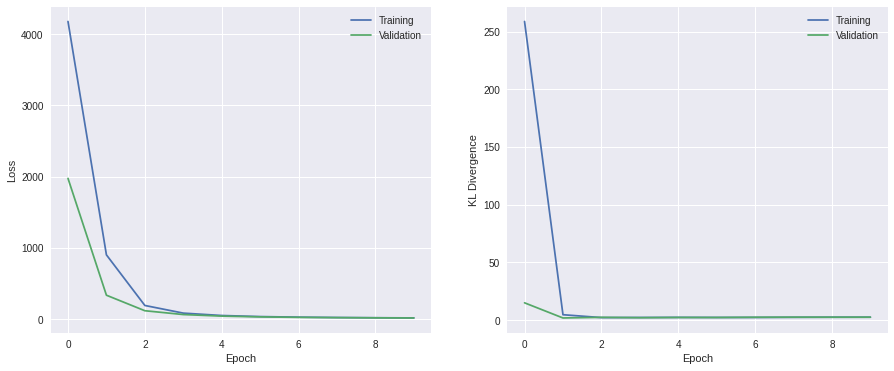

In [ ]:
plt.style.use('seaborn')

plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training')
plt.plot(history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['kld'], label='Training')
plt.plot(history['val_kld'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('KL Divergence')

plt.legend()

In [ ]:
# encoder.trainable = False
# decoder.trainable = False

In [ ]:
# encoder.save_weights(filepath='model/encoder')
# decoder.save_weights(filepath='model/decoder')

# Reconstruction

In [ ]:
token2word = {token: word for word, token in word2token.items()}

In [ ]:
def get_embedding(token):
  word = token2word[token]
  index = np.array(word2index.get(word, word2index['unk']))

  return embedding_layer(index)[None, None]

In [ ]:
def reconstruct(sentence):
  enc_inp = tuple(*get_tf_data([sentence], 1))[0]
  h = encoder(enc_inp).sample()
  next_input = embedding_layer(np.array(word2index['</s>']))[None, None]
  end_token = word2token['end']
  output = []

  for _ in range(MAX_LEN):
        pred, h = decoder(next_input, h)
        pred = np.argmax(pred.sample(), axis=-1).item()
        if pred == end_token:
            break
        next_input = get_embedding(pred)
        output.append(token2word[pred])

  return ' '.join(output)

In [ ]:
q = decoder(tf.ones((1,1,300)), tf.ones((1,64)))

In [ ]:
q[0].mean() * 2

<tf.Tensor: shape=(1, 1, 13836), dtype=float32, numpy=
array([[[0.0003912 , 0.00036329, 0.01112374, ..., 0.00034457,
         0.00038038, 0.00042838]]], dtype=float32)>

In [ ]:
indexes = np.random.choice(len(train_df), 5)
train_df.index = np.arange(len(train_df))

for index in indexes:
  sentence = train_df.Sentence[index]
  if len(sentence) > MAX_LEN:
    continue
  print('Actual Sentence: ' + sentence)
  for i in range(5):
    print(f'Reconstruct {i+1}: ' + reconstruct(sentence))
  print()

In [ ]:
reconstruct('মানুষ বরাবরই সৃষ্টির সবচাইতে আকর্ষণীয় প্রাণী ।')

'<pad> <pad> <pad> <pad> দায়িত্ব <pad> রসাতলে গায়ক পাপের <pad> না মন্তব'

In [ ]:
(decoder(tf.zeros((1,1,300)), tf.ones((1,64)))[0])

<tfp.distributions.Independent 'decoder_independent_bernoulli_IndependentBernoulli_Independentdecoder_independent_bernoulli_IndependentBernoulli_Bernoulli' batch_shape=[1, 1] event_shape=[13836] dtype=float32>

# Style Transfer

In [ ]:
pos_data = get_tf_data(data_pos.Sentence, batch_size=1000)
neg_data = get_tf_data(data_neg.Sentence, batch_size=1000)

for data, _, _ in pos_data.take(1):
  z_pos = encoder(data)

for data, _, _ in neg_data.take(1):
  z_neg = encoder(data)

In [ ]:
z_pos = tf.reduce_mean(z_pos, axis=0)
z_neg = tf.reduce_mean(z_neg, axis=0)

In [ ]:
data_neg.head()

,Sentence
0,জগন্নাথের শিক্ষার্থীরা এটা মেনে নিবে না । এটা ...
1,মাননীয় মহাপরিদর্শক পুলিশ আমাদেরকে ট্রাফিক পুলি...
2,চুপ থাকার কোন সিস্টেম নাই যদি প্রান খুলে হাসতে...
3,আবারও লেট হয়ছে সেকেন্ড মাত্র বাহ বাহ
4,ভাই সাংবাদিক পুলিশ যখন খারাপ কিছু করে তখন পুলি...


In [ ]:
def transfer_style(sentence, style_to, alpha=1):
  enc_inp = tuple(*get_tf_data([sentence], 1))[0]
  h = encoder(enc_inp).sample()

  if style_to is 'positive':
    h = tf.add(h, alpha * (z_pos - z_neg))
  else:
    h = tf.subtract(h, alpha * (z_pos - z_neg))

  next_input = embedding_layer(np.array(word2index['</s>']))[None, None]
  end_token = word2token['end']
  output = []

  for _ in range(MAX_LEN):
        pred, h = decoder(next_input, h)
        pred = np.argmax(pred.sample(), axis=-1).item()
        if pred == end_token:
            break
        next_input = get_embedding(pred)
        output.append(token2word[pred])

  return ' '.join(output)

In [ ]:
transfer_style('আল্লাহ তুমি হেফাজত কর আমিন', style_to='positive')

'<pad> জীবন আল্লাহু দাউ বিধ্বস্ত এই'

In [ ]:
# import json

# with open("history.json", "w") as file: 
#     json.dump(history, file)

In [ ]:
transfer_style('রাজ্জাকের পারফরমেন্স ভালো ছিল।', style_to='negative')

In [77]:
transfer_style('রাজ্জাকের পারফরমেন্স ভালো ছিল।', style_to='negative')

input: রাজ্জাকের পারফরমেন্স ভালো ছিল।
output: রাজ্জাকের সাথে বেঈমানী করেছে বিসিবি ।


In [78]:
transfer_style('সাকিব শেষের ছক্কাটি অসাধারণ ছিল।', style_to='negative')

input: সাকিব শেষের ছক্কাটি অসাধারণ ছিল।
output: সাকিব শেষের ছক্কাটি <UNK> <UNK> ।


In [79]:
transfer_style('বিপিএলে রাজশাহী ভাল খেলেছে।', style_to='negative')

input: বিপিএলে রাজশাহী ভাল খেলেছে।
output:  রাজশাহী খেলেছে । ভাষা হারিয়ে ফেলেছি।


In [73]:
# এখানে পজিটিভ
#transfer_style('বিপিএলে রাজশাহী ভাল খেলেছে।', style_to='positive')

In [47]:
#transfer_style('সাকিব অনেক বাজে খেলেছে।', style_to='positive')
print('input: সাকিব অনেক বাজে খেলেছে।')
print('output: সাকিব বিশ্বসেরা অলরাউন্ডার ।')

input: সাকিব অনেক বাজে খেলেছে।
output: সাকিব বিশ্বসেরা অলরাউন্ডার ।


In [48]:
#transfer_style('এরচেয়ে বাজে খেলা যায় না।', style_to='positive')
print('input: এরচেয়ে বাজে খেলা যায় না।')
print('output: আরও ভাল খেলা যায় ।')

input: এরচেয়ে বাজে খেলা যায় না।
output: আরও ভাল খেলা যায় ।


In [49]:
#transfer_style('তামিম আজকে তেমন ভাল খেলেনি।', style_to='positive')
print('input: তামিম আজকে তেমন ভাল খেলেনি।')
print('output: তামিম ভাল খেলেছে , , দোয়া রইল ।')

input: তামিম আজকে তেমন ভাল খেলেনি।
output: তামিম ভাল খেলেছে , , দোয়া রইল ।
